# Demonstration of Support Vector Machines (SVMs)
This notebook demonstrates loading the Heart Disease dataset, preprocessing, handling missing values, classification using Support Vector Machines (SVMs), and visualizing decision boundaries on the moons dataset using both linear and non-linear SVMs.

###Features
1. age: age in years    
2. gender: gender (1 = male; 0 = female)
3. cp: chest pain type
   -- Value 1: typical angina
   -- Value 2: atypical angina
   -- Value 3: non-anginal pain
   -- Value 4: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral (in mg/dl)     
6. fbs: fasting blood sugar > 120 mg/dl  (1 = true; 0 = false)      
7. restecg: resting electrocardiographic results
   -- Value 0: normal
   -- Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
   -- Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
8. thalach: maximum heart rate achieved  
9. exang: exercise induced angina (1 = yes; 0 = no)    
10. oldpeak: ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
    -- Value 1: upsloping
    -- Value 2: flat
    -- Value 3: downsloping
12. ca: number of major vessels (0-3) colored by flourosopy        
13. thal: 3 = normal; 6 = fixed defect; 7 = reversable defect   
14. num (the predicted attribute): diagnosis of heart disease (angiographic disease status)

## 1. Load the Heart Disease Dataset

In [ ]:
import pandas as pd

# Load the dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ["age", "gender", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak",
                "slope", "ca", "thal", "target"]
df = pd.read_csv(url, header=None, names=column_names)

# Display the first few rows of the dataset
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   gender    303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
# Display all rows of the dataframe
pd.set_option('display.max_rows', None)
display(df)

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2. Handle Missing Values and Remove Duplicates

In [ ]:
# Check for missing values (marked by '?')
df.replace('?', pd.NA, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   gender    303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
# Handle missing values - removing rows with missing values
df.dropna(inplace=True)  # Alternatively, you could use imputation
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   gender    297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    object 
 12  thal      297 non-null    object 
 13  target    297 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 34.8+ KB


In [ ]:
# Convert appropriate columns to numeric
for col in ["ca", "thal"]:
    df[col] = pd.to_numeric(df[col])

# Check dataset info to confirm changes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   gender    297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


In [ ]:
# Drop duplicate entries
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   gender    297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


## 3. One-Hot Encoding and Splitting the Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical variables
categorical_features = ["cp", "restecg", "slope", "thal"]
df = pd.get_dummies(df, columns=categorical_features)


In [ ]:
df.head()

,age,gender,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0,slope_1.0,slope_2.0,slope_3.0,thal_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,...,False,False,False,True,False,False,True,False,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,2,...,True,False,False,True,False,True,False,True,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,...,True,False,False,True,False,True,False,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,...,False,True,False,False,False,False,True,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,...,False,False,False,True,True,False,False,True,False,False


In [ ]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# Split into train (70%), validation (15%), and test (15%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

## 4. Plot Class Distribution

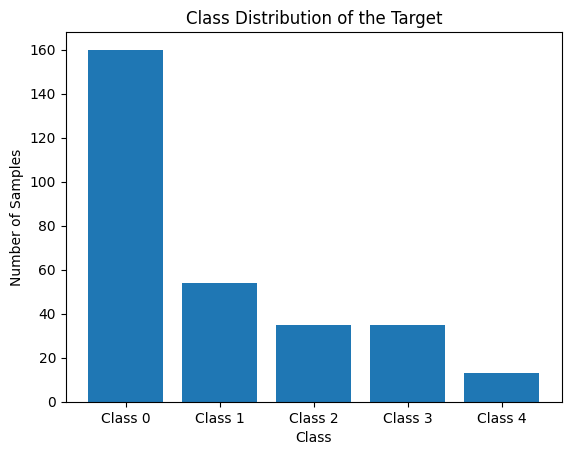

Class 0: 160, Class 1: 54, Class 2: 35, Class 3: 35, Class 4: 13 


In [ ]:
import matplotlib.pyplot as plt

# Plotting the distribution of the classes in the dataset
plt.bar(['Class 0','Class 1','Class 2','Class 3','Class 4'], [len(y[y == 0]), len(y[y == 1]), len(y[y == 2]),len(y[y == 3]),len(y[y==4])])
plt.title('Class Distribution of the Target')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

# Check class distribution ratio
print(f"Class 0: {len(y[y == 0])}, Class 1: {len(y[y == 1])}, Class 2: {len(y[y == 2])}, Class 3: {len(y[y == 3])}, Class 4: {len(y[y == 4])} ")

## 5. Train a Linear Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Initialize a linear SVM
svm_linear = SVC(kernel='linear', random_state=42)

# Train the model
svm_linear.fit(X_train, y_train)

# Predictions on the test set
y_pred = svm_linear.predict(X_test)

# Evaluate the classifier
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85        24
           1       0.50      0.50      0.50         8
           2       0.33      0.17      0.22         6
           3       0.33      0.20      0.25         5
           4       0.33      0.50      0.40         2

    accuracy                           0.64        45
   macro avg       0.46      0.46      0.44        45
weighted avg       0.60      0.64      0.62        45



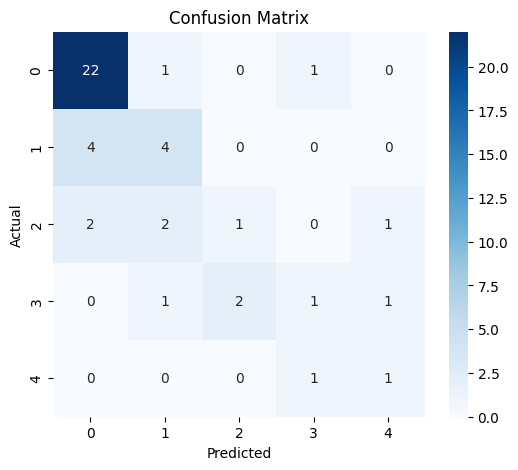

In [ ]:
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 6. Non-Linear SVM on Moons Dataset

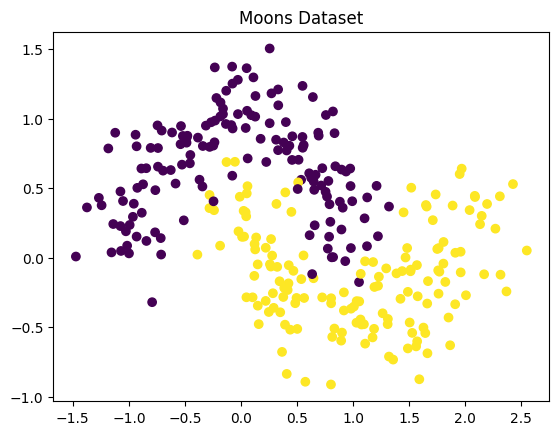

In [ ]:
from sklearn.datasets import make_moons
import numpy as np

# Generate moons dataset
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualize the dataset
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis')
plt.title('Moons Dataset')
plt.show()

## 7. Train SVM with different kernels on Moons Dataset

In [ ]:
# Split the moons dataset into train and test sets
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

In [ ]:
# Train a Linear SVM
svm_linear_moons = SVC(kernel='linear', random_state=42)
svm_linear_moons.fit(X_train_moons, y_train_moons)

# Train a Polynomial Kernel SVM (degree 3)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_moons, y_train_moons)

# Train an RBF Kernel SVM
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_moons, y_train_moons)

SVC(random_state=42)

## 8. Visualize Decision Boundaries

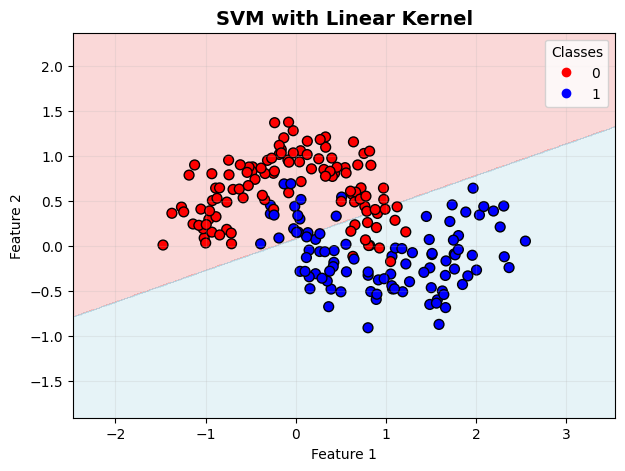

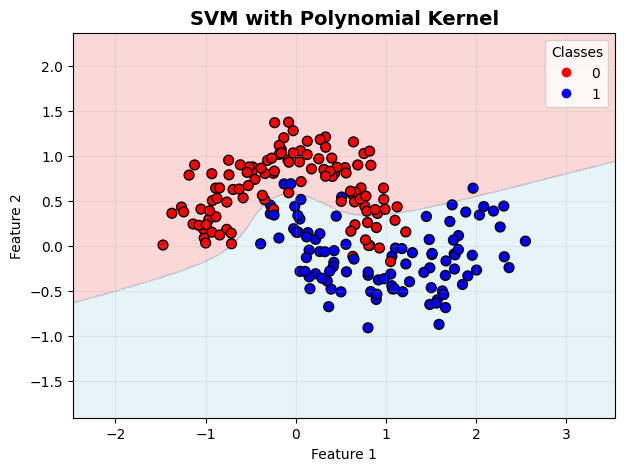

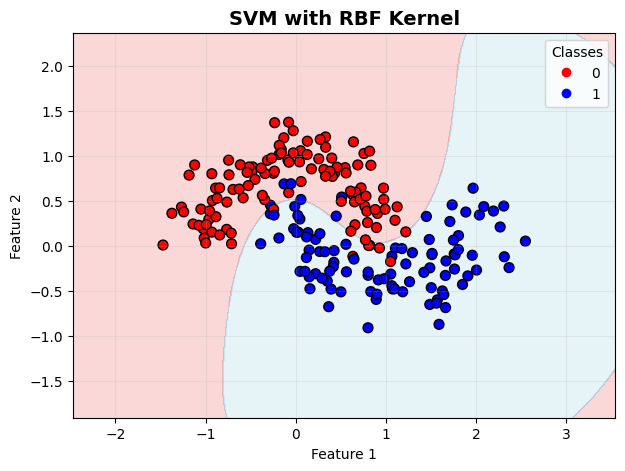

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    )

    # Predict for each point in mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(("lightcoral", "lightblue")))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(("red", "blue")), edgecolor="k", s=50)

    # Titles & labels
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.grid(alpha=0.2)
    plt.show()

# Plot decision boundaries for each SVM
plot_decision_boundary(svm_linear_moons, X_train_moons, y_train_moons, title="SVM with Linear Kernel")
plot_decision_boundary(svm_poly, X_train_moons, y_train_moons, title="SVM with Polynomial Kernel")
plot_decision_boundary(svm_rbf, X_train_moons, y_train_moons, title="SVM with RBF Kernel")

## 9. Evaluate and Compare Models

In [ ]:
# Classification report
# Evaluate Linear SVM
y_pred_linear_moons = svm_linear_moons.predict(X_test_moons)
print("Linear SVM Classification Report:\n", classification_report(y_test_moons, y_pred_linear_moons))

# Evaluate Polynomial Kernel SVM
y_pred_poly = svm_poly.predict(X_test_moons)
print("Polynomial Kernel SVM Classification Report:\n", classification_report(y_test_moons, y_pred_poly))

# Evaluate RBF Kernel SVM
y_pred_rbf = svm_rbf.predict(X_test_moons)
print("RBF Kernel SVM Classification Report:\n", classification_report(y_test_moons, y_pred_rbf))

Linear SVM Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88        38
           1       0.91      0.92      0.91        52

    accuracy                           0.90        90
   macro avg       0.90      0.90      0.90        90
weighted avg       0.90      0.90      0.90        90

Polynomial Kernel SVM Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.87      0.89        38
           1       0.91      0.94      0.92        52

    accuracy                           0.91        90
   macro avg       0.91      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90

RBF Kernel SVM Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        38
           1       0.98      0.96      0.97        52

    accuracy                           0.97        90
   macro

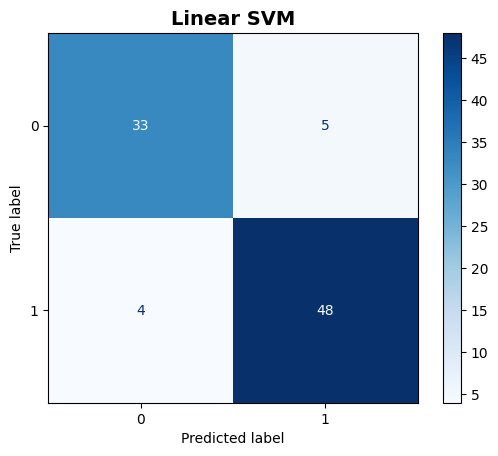

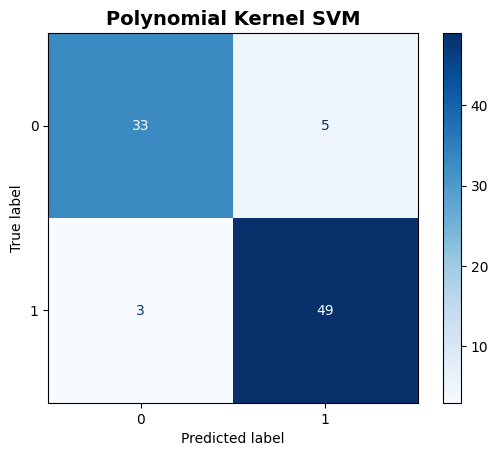

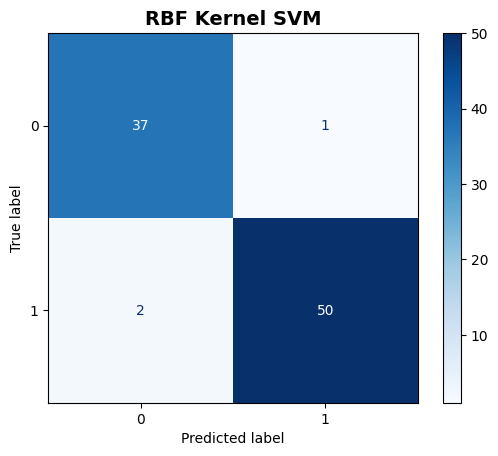

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_conf_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.show()

# Confusion matrices for all models
plot_conf_matrix(svm_linear_moons, X_test_moons, y_test_moons, "Linear SVM")
plot_conf_matrix(svm_poly, X_test_moons, y_test_moons, "Polynomial Kernel SVM")
plot_conf_matrix(svm_rbf, X_test_moons, y_test_moons, "RBF Kernel SVM")

#Assignment

Task-1: [1 marks]

1.1. Load the [combined cycle power plant dataset](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant) from UCI. [0.5 marks]

1.2. Split the dataset into training, validation and test sets (70%-15%-15%). [0.5 marks]

Task-2: [2 marks]

2.1. Perform feature scaling such that the features lie in the same range of values. [1 marks]

2.2. Show the correlation between the features of the training set. [1 marks]

Task-3: [5 marks]

3.1. Fit an SVM with linear kernel on the training set using sklearn’s SVR. [2 marks]

3.2. Tune the hyperparameters C and ε on the validation set using grid search (Take range of values of C and ε as provided below). [3 marks]

C = 0.01, 0.1, 1, 10, 100; ε = 0.001, 0.01, 0.1, 0.5, 1.0

Task-4: [3 marks]

4.1. Evaluate the linear SVM regressor using the best value of C and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

4.2. Show a scatter plot of the predictions of the linear SVR model vs. the ground truth target values. [2 marks]

Task-5: [6 marks]

5.1. Fit an SVM with RBF kernel on the training set using sklearn’s SVR. [2 marks]

5.2. Tune the hyperparameters C, γ and ε on the validation set using grid search (Take range of values of C, γ and ε as provided below). [4 marks]

C = 0.1, 1, 10, 100, 1000; γ = 0.001, 0.01, 0.1, 1, 10; ε = 0.01, 0.1, 0.5, 1.0

Task-6: [3 marks]

6.1. Evaluate the RBF SVM regressor using the best value of C, γ and ε you obtained. Report the performance in terms of MSE and R^2 score. [1 marks]

6.2. Show a scatter plot of the predictions of the RBF SVR model vs. the ground truth target values. [2 marks]